# Traffic Prediction


#### Importing the Libraries

In [109]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, precision_recall_fscore_support, accuracy_score

import warnings
warnings.filterwarnings('ignore')

import tensorflow as tf
from tensorflow import keras
from keras import layers, Sequential
from tensorflow.keras.callbacks import EarlyStopping

import warnings
warnings.filterwarnings('ignore')

### loading the data

In [78]:
df = pd.read_csv('/TrafficTwoMonth.csv')
df

,Time,Date,Day of the week,CarCount,BikeCount,BusCount,TruckCount,Total,Traffic Situation
0,12:00:00 AM,10,Tuesday,13,2,2,24,41,normal
1,12:15:00 AM,10,Tuesday,14,1,1,36,52,normal
2,12:30:00 AM,10,Tuesday,10,2,2,32,46,normal
3,12:45:00 AM,10,Tuesday,10,2,2,36,50,normal
4,1:00:00 AM,10,Tuesday,11,2,1,34,48,normal
...,...,...,...,...,...,...,...,...,...
5947,10:45:00 PM,9,Thursday,16,3,1,36,56,normal
5948,11:00:00 PM,9,Thursday,11,0,1,30,42,normal
5949,11:15:00 PM,9,Thursday,15,4,1,25,45,normal
5950,11:30:00 PM,9,Thursday,16,5,0,27,48,normal


In [79]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5952 entries, 0 to 5951
Data columns (total 9 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   Time               5952 non-null   object
 1   Date               5952 non-null   int64 
 2   Day of the week    5952 non-null   object
 3   CarCount           5952 non-null   int64 
 4   BikeCount          5952 non-null   int64 
 5   BusCount           5952 non-null   int64 
 6   TruckCount         5952 non-null   int64 
 7   Total              5952 non-null   int64 
 8   Traffic Situation  5952 non-null   object
dtypes: int64(6), object(3)
memory usage: 418.6+ KB


#### checking for the nulls

In [80]:
df.isna().sum()

,0
Time,0
Date,0
Day of the week,0
CarCount,0
BikeCount,0
BusCount,0
TruckCount,0
Total,0
Traffic Situation,0


#### EDA

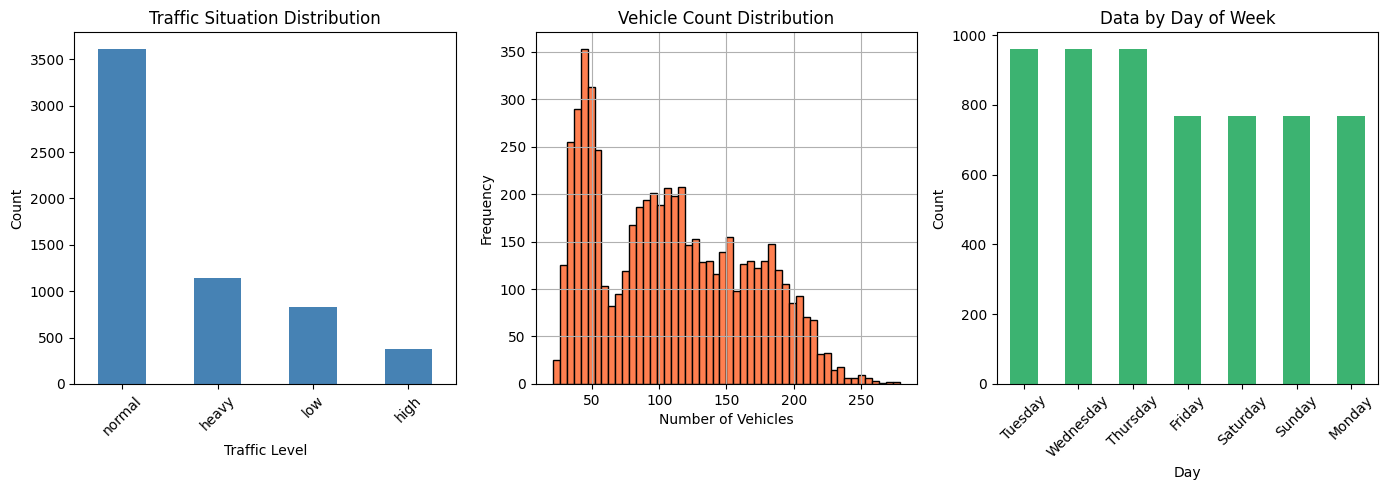

In [81]:
plt.figure(figsize=(14, 5))

plt.subplot(1, 3, 1)
df['Traffic Situation'].value_counts().plot(kind='bar', color='steelblue')
plt.title('Traffic Situation Distribution')
plt.xlabel('Traffic Level')
plt.ylabel('Count')
plt.xticks(rotation=45)

plt.subplot(1, 3, 2)
df['Total'].hist(bins=50, color='coral', edgecolor='black')
plt.title('Vehicle Count Distribution')
plt.xlabel('Number of Vehicles')
plt.ylabel('Frequency')

plt.subplot(1, 3, 3)
df['Day of the week'].value_counts().plot(kind='bar', color='mediumseagreen')
plt.title('Data by Day of Week')
plt.xlabel('Day')
plt.ylabel('Count')
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

#### Data cleaning

In [82]:
df['Hour'] = pd.to_datetime(df['Time'], format='%I:%M:%S %p').dt.hour

day_map = {
    'Monday': 0,
    'Tuesday': 1,
    'Wednesday': 2,
    'Thursday': 3,
    'Friday': 4,
    'Saturday': 5,
    'Sunday': 6
}
df['DayNum'] = df['Day of the week'].map(day_map)

df['is_morning_rush'] = ((df['Hour'] >= 7) & (df['Hour'] <= 9)).astype(int)
df['is_evening_rush'] = ((df['Hour'] >= 16) & (df['Hour'] <= 19)).astype(int)
df['is_night'] = ((df['Hour'] >= 22) | (df['Hour'] < 4)).astype(int)
df['is_weekend'] = (df['DayNum'] >= 5).astype(int)

print(f"Processed {len(df)} records")
print(f"\nTraffic situations: {df['Traffic Situation'].unique()}")
print(f"\nTraffic distribution:")
print(df['Traffic Situation'].value_counts())
print(f"\nFeatures created:")
print(f"  - Hour (0-23)")
print(f"  - DayNum (0-6)")
print(f"  - is_morning_rush")
print(f"  - is_evening_rush")
print(f"  - is_night")
print(f"  - is_weekend")

Processed 5952 records

Traffic situations: ['normal' 'low' 'heavy' 'high']

Traffic distribution:
Traffic Situation
normal    3610
heavy     1137
low        834
high       371
Name: count, dtype: int64

Features created:
  - Hour (0-23)
  - DayNum (0-6)
  - is_morning_rush
  - is_evening_rush
  - is_night
  - is_weekend


In [83]:
df['Traffic Situation'] = df['Traffic Situation'].map({'heavy':0,'high':1,'normal':2,'low':3})

In [84]:
df['Minute'] = pd.to_datetime(df['Time'], format='%I:%M:%S %p').dt.minute

In [85]:
df.head()

,Time,Date,Day of the week,CarCount,BikeCount,BusCount,TruckCount,Total,Traffic Situation,Hour,DayNum,is_morning_rush,is_evening_rush,is_night,is_weekend,Minute
0,12:00:00 AM,10,Tuesday,13,2,2,24,41,2,0,1,0,0,1,0,0
1,12:15:00 AM,10,Tuesday,14,1,1,36,52,2,0,1,0,0,1,0,15
2,12:30:00 AM,10,Tuesday,10,2,2,32,46,2,0,1,0,0,1,0,30
3,12:45:00 AM,10,Tuesday,10,2,2,36,50,2,0,1,0,0,1,0,45
4,1:00:00 AM,10,Tuesday,11,2,1,34,48,2,1,1,0,0,1,0,0


#### splitting the data into X and Y

In [86]:
X = df[['Total', 'Hour', 'Minute', 'DayNum','is_morning_rush', 'is_evening_rush', 'is_night', 'is_weekend']]
y = df['Traffic Situation']

In [87]:
x_train, x_test, y_train, y_test = train_test_split(X,y,test_size=0.25,random_state=42)
print('X_train: ',x_train.shape)
print('Y_train: ',y_train.shape)

X_train:  (4464, 8)
Y_train:  (4464,)


#### Scaaling the data

In [88]:
scaler = StandardScaler()
x_train = scaler.fit_transform(x_train)
x_test = scaler.transform(x_test)

#### Model Creation

In [101]:
model = keras.Sequential([
    keras.layers.Dense(128, activation='relu',input_shape=(8,)),
    keras.layers.Dropout(0.3),
    keras.layers.Dense(128 // 2, activation='relu'),
    keras.layers.Dropout(0.2),
    keras.layers.Dense(4, activation='softmax')
])

model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

callback = EarlyStopping(
    monitor="val_loss",
    patience=15,
    verbose=1,
    mode="auto",
    baseline=None,
    restore_best_weights=True
)

print("Model architecture:")
model.summary()

total_params = model.count_params()
print(f"\nTotal parameters: {total_params:,}")


Model architecture:


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_9 (Dense)                 │ (None, 128)            │         1,152 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 4)              │           260 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 9,668 (37.77 KB)

 Trainable params: 9,668 (37.77 KB)

 Non-trainable params: 0 (0.00 B)


Total parameters: 9,668


#### training the model

In [102]:
history = model.fit(x_train, y_train, validation_data=(x_test, y_test), epochs=100, callbacks=callback)

Epoch 1/100
140/140 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.5927 - loss: 1.0418 - val_accuracy: 0.7688 - val_loss: 0.6278
Epoch 2/100
140/140 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.7574 - loss: 0.6475 - val_accuracy: 0.7950 - val_loss: 0.5453
Epoch 3/100
140/140 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7760 - loss: 0.5673 - val_accuracy: 0.7957 - val_loss: 0.5291
Epoch 4/100
140/140 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7962 - loss: 0.5325 - val_accuracy: 0.8024 - val_loss: 0.5129
Epoch 5/100
140/140 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7780 - loss: 0.5354 - val_accuracy: 0.8011 - val_loss: 0.5007
Epoch 6/100
140/140 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7997 - loss: 0.5075 - val_accuracy: 0.8065 - val_loss: 0.4894
Epoch 7/100
140/140 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7969 - loss: 0.4890 - val_accuracy: 0.8138 - val_loss: 0.4893
Epoch 8/100
140/140 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7934 - loss: 0.5034 - val_accu

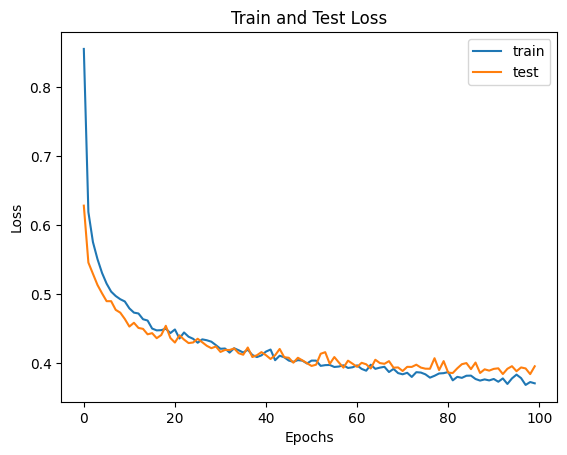

In [103]:
plt.plot(history.history['loss'], label='train')
plt.plot(history.history['val_loss'], label='test')
plt.legend()
plt.title('Train and Test Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.show()

#### Evaluating the model

In [104]:

test_loss, test_accuracy = model.evaluate(x_test, y_test)
print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_accuracy:.4f}")


47/47 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8209 - loss: 0.3666
Test Loss: 0.3837
Test Accuracy: 0.8219


In [105]:
y_pred_probs = model.predict(x_test, verbose=0)
y_pred = np.argmax(y_pred_probs, axis=1)

In [106]:
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=['heavy', 'high', 'normal', 'low']))


Classification Report:
              precision    recall  f1-score   support

       heavy       0.96      0.99      0.98       266
        high       0.55      0.16      0.24       102
      normal       0.83      0.90      0.87       941
         low       0.56      0.53      0.54       179

    accuracy                           0.82      1488
   macro avg       0.73      0.64      0.66      1488
weighted avg       0.81      0.82      0.81      1488



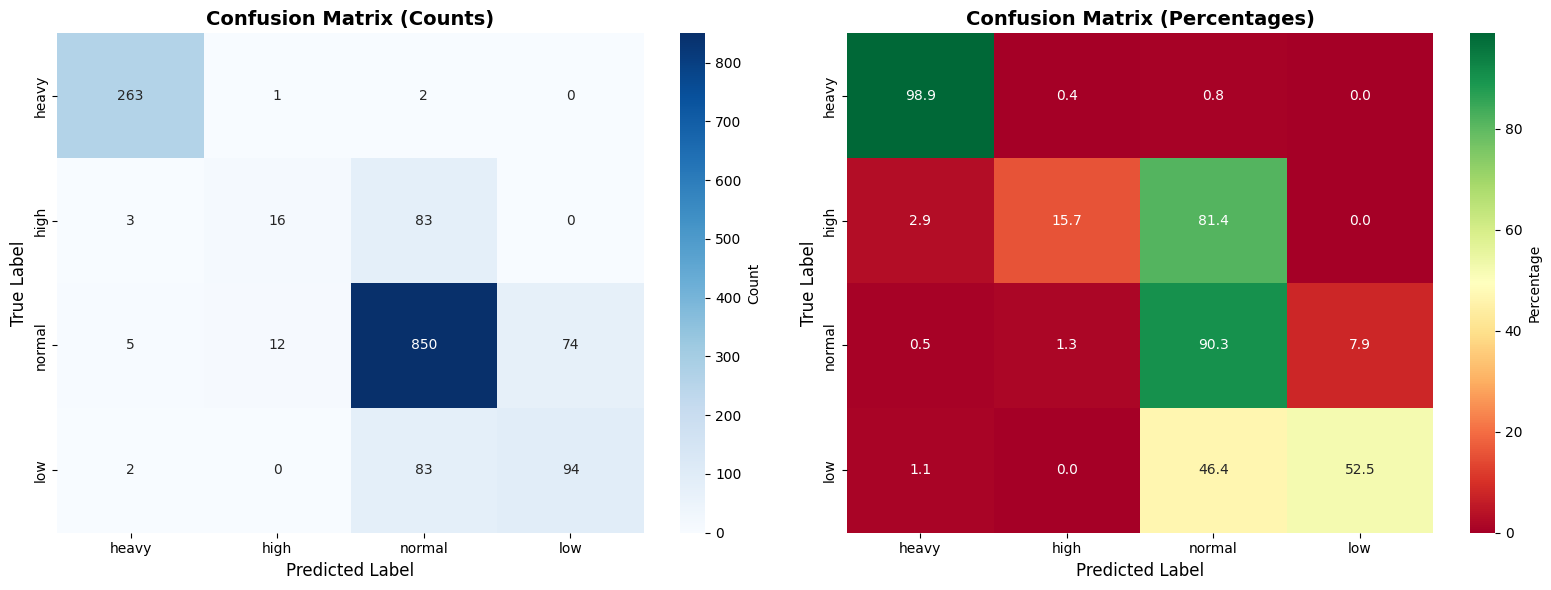

In [107]:
cm = confusion_matrix(y_test, y_pred)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['heavy', 'high', 'normal', 'low'],
            yticklabels=['heavy', 'high', 'normal', 'low'],
            ax=axes[0],
            cbar_kws={'label': 'Count'})
axes[0].set_xlabel('Predicted Label', fontsize=12)
axes[0].set_ylabel('True Label', fontsize=12)
axes[0].set_title('Confusion Matrix (Counts)', fontsize=14, fontweight='bold')

cm_percent = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis] * 100
sns.heatmap(cm_percent, annot=True, fmt='.1f', cmap='RdYlGn',
            xticklabels=['heavy', 'high', 'normal', 'low'],
            yticklabels=['heavy', 'high', 'normal', 'low'],
            ax=axes[1],
            cbar_kws={'label': 'Percentage'})
axes[1].set_xlabel('Predicted Label', fontsize=12)
axes[1].set_ylabel('True Label', fontsize=12)
axes[1].set_title('Confusion Matrix (Percentages)', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

(0.0, 1.1)

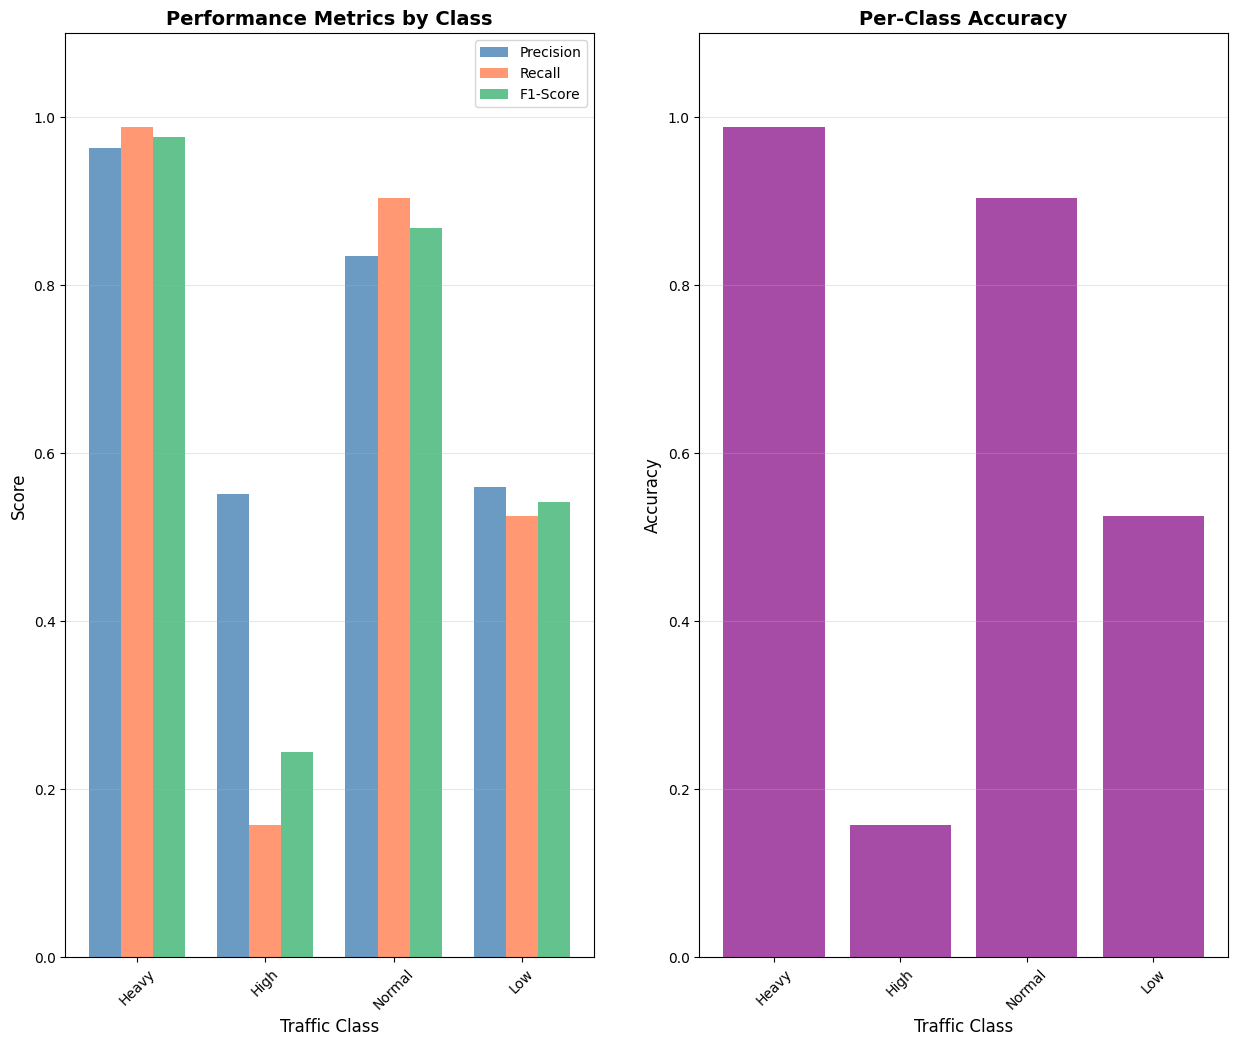

In [111]:
precision, recall, f1, support = precision_recall_fscore_support(
    y_test, y_pred, average=None, labels=range(4)
)

fig, axes = plt.subplots(1, 2, figsize=(15, 12))

metrics_df = pd.DataFrame({
    'Class': ['Heavy', 'High', 'Normal', 'Low'],
    'Precision': precision,
    'Recall': recall,
    'F1-Score': f1
})

x = np.arange(4)
width = 0.25

axes[0].bar(x - width, precision, width, label='Precision', alpha=0.8, color='steelblue')
axes[0].bar(x, recall, width, label='Recall', alpha=0.8, color='coral')
axes[0].bar(x + width, f1, width, label='F1-Score', alpha=0.8, color='mediumseagreen')
axes[0].set_xlabel('Traffic Class', fontsize=12)
axes[0].set_ylabel('Score', fontsize=12)
axes[0].set_title('Performance Metrics by Class', fontsize=14, fontweight='bold')
axes[0].set_xticks(x)
axes[0].set_xticklabels(['Heavy', 'High', 'Normal', 'Low'], rotation=45)
axes[0].legend()
axes[0].grid(True, alpha=0.3, axis='y')
axes[0].set_ylim([0, 1.1])

class_accuracy = []
for i in range(4):
    mask = y_test == i
    class_acc = accuracy_score(y_test[mask], y_pred[mask])
    class_accuracy.append(class_acc)

axes[1].bar(['Heavy', 'High', 'Normal', 'Low'], class_accuracy, color='purple', alpha=0.7)
axes[1].set_xlabel('Traffic Class', fontsize=12)
axes[1].set_ylabel('Accuracy', fontsize=12)
axes[1].set_title('Per-Class Accuracy', fontsize=14, fontweight='bold')
axes[1].tick_params(axis='x', rotation=45)
axes[1].grid(True, alpha=0.3, axis='y')
axes[1].set_ylim([0, 1.1])

In [116]:
X.iloc[5933]

,5933
Total,161
Hour,19
Minute,15
DayNum,3
is_morning_rush,0
is_evening_rush,1
is_night,0
is_weekend,0


In [118]:
y.iloc[5933]

np.int64(2)

### Prediction For New data

In [117]:

new_data = [[161, 19, 15, 3, 0, 1, 0, 0]]
new_data = scaler.transform(new_data)

prediction = model.predict(new_data)

predicted_class = np.argmax(prediction, axis=1)
print(predicted_class)

if predicted_class == 0:
    print('Traffic is Heavy')
elif predicted_class == 1:
    print('Traffic is High')
elif predicted_class == 2:
    print('Traffic is Normal')
elif predicted_class == 3:
    print('Traffic is Low')





1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step
[2]
Traffic is Normal
